# Iris 데이터셋을 이용한 DBSCAN 클러스터링 분석

> 원본 실습파일(`02. 머신러닝 심화 DBSCAN Clustering.ipynb`)은 Wine 데이터셋을 사용합니다. 과제 지시에 따라 `load_wine` → `load_iris`로 교체하여 동일한 파이프라인을 그대로 적용했습니다.

sklearn의 Iris 데이터셋에 DBSCAN 알고리즘을 적용하여 밀도 기반 클러스터링을 수행

## 주요 내용
1. 데이터 로드 및 전처리
2. PCA를 이용한 차원 축소
3. K-Distance Plot을 통한 최적 epsilon 찾기
4. DBSCAN 모델 적용
5. 결과 시각화
6. (추가) 실제 품종 라벨과의 일치도 확인

## 필요한 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

## 1. 데이터 로드 및 전처리 (Iris 데이터셋)

- Iris 데이터셋은 150개의 샘플과 4개의 피처(꽃받침 길이/너비, 꽃잎 길이/너비)를 가진 데이터셋
- StandardScaler로 정규화

In [2]:
# 실습파일에서 데이터를 가져온 형태
# from sklearn.datasets import load_wine
# wine = load_wine()

# 과제를 수행하기 위해서 변경하여 적용해야하는 형태
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y_true = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"데이터 크기: {X.shape}")
print(f"\n데이터 미리보기:\n{X.head()}")

데이터 크기: (150, 4)

데이터 미리보기:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## 2. 차원 축소 (PCA)

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"설명된 분산 비율: {pca.explained_variance_ratio_}")
print(f"총 설명된 분산: {sum(pca.explained_variance_ratio_):.2%}")

설명된 분산 비율: [0.72962445 0.22850762]
총 설명된 분산: 95.81%


## 3. 적절한 Epsilon(eps) 찾기: K-Distance Plot

- DBSCAN의 핵심 파라미터인 epsilon(eps)을 결정하기 위해 K-Distance Plot 작성
- min_samples를 5로 설정하고 각 점에서 5번째 이웃까지의 거리를 계산
- 그래프에서 급격히 꺾이는 지점(Elbow)의 Y값 부근을 eps 후보로 사용

C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\2455674214.py:15: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\2455674214.py:15: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\2455674214.py:15: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\2455674214.py:15: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\2455674214.py:15: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\2455674214.py:15: UserWarning: Glyph 53944 (\N{HANGUL S

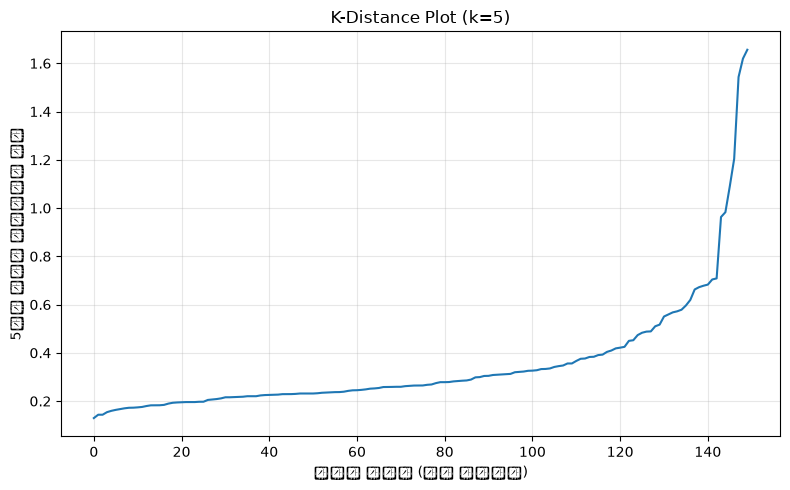

k-distance 최소값: 0.1297, 최대값: 1.6561
90 퍼센타일 지점 거리: 0.5805


In [4]:
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# k번째 이웃까지의 거리만 추출 후 오름차순 정렬
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"K-Distance Plot (k={k})")
plt.xlabel("데이터 포인트 (거리 오름차순)")
plt.ylabel(f"{k}번째 최근접 이웃까지의 거리")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_kdistance.png", dpi=100)
plt.show()

print(f"k-distance 최소값: {k_distances.min():.4f}, 최대값: {k_distances.max():.4f}")
print(f"90 퍼센타일 지점 거리: {np.percentile(k_distances, 90):.4f}")

## 4. DBSCAN 모델 적용

K-Distance Plot에서 그래프가 급격히 꺾이는 지점(약 90 퍼센타일 부근)의 거리값을 eps로 채택. Iris는 Wine보다 차원이 낮고 표준화된 값의 스케일도 작아, Wine 실습의 0.5~0.7보다 작은 값이 적절했다 (아래 셀에서 실제 계산된 90퍼센타일 값을 그대로 사용).

In [5]:
eps_value = round(float(np.percentile(k_distances, 90)), 2)
print(f"채택한 eps: {eps_value}")

dbscan = DBSCAN(eps=eps_value, min_samples=5)
clusters = dbscan.fit_predict(X_pca)

unique_labels = np.unique(clusters)
print(f"발견된 클러스터 값: {unique_labels}")

for label in unique_labels:
    count = np.sum(clusters == label)
    if label == -1:
        print(f"노이즈(Outlier): {count}개")
    else:
        print(f"클러스터 {label}: {count}개")

채택한 eps: 0.58
발견된 클러스터 값: [-1  0  1]
노이즈(Outlier): 6개
클러스터 0: 48개
클러스터 1: 96개


## 5. 결과 시각화

- 노이즈(Outlier, label=-1)는 회색 'x'로 표시

C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\1998949498.py:14: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\1998949498.py:14: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\1998949498.py:14: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\1998949498.py:14: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\1998949498.py:14: UserWarning: Glyph 47553 (\N{HANGUL SYLLABLE RING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kimjongmin\AppData\Local\Temp\ipykernel_12440\1998949498.py:14: UserWarning: Glyph 45432 (\N{H

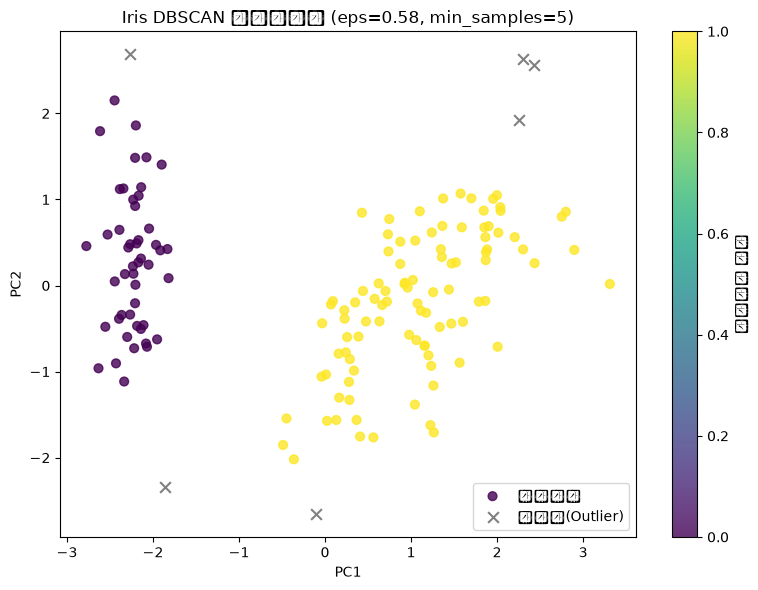

In [6]:
plt.figure(figsize=(8, 6))
core_mask = clusters != -1

scatter = plt.scatter(X_pca[core_mask, 0], X_pca[core_mask, 1],
                       c=clusters[core_mask], cmap="viridis", s=40, alpha=0.8, label="클러스터")
plt.scatter(X_pca[~core_mask, 0], X_pca[~core_mask, 1],
            c="gray", marker="x", s=60, label="노이즈(Outlier)")

plt.title(f"Iris DBSCAN 클러스터링 (eps={eps_value}, min_samples=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.colorbar(scatter, label="클러스터 라벨")
plt.tight_layout()
plt.savefig("dbscan_result.png", dpi=100)
plt.show()

## 6. (추가) 실제 품종 라벨과의 일치도

노이즈로 분류된 포인트(label=-1)는 ARI 계산에 포함하면 왜곡이 생기므로, 노이즈를 제외한 포인트만으로 실제 품종과의 일치도를 확인한다.

In [7]:
ari = adjusted_rand_score(y_true[core_mask], clusters[core_mask])
print(f"Adjusted Rand Index (노이즈 제외, 클러스터 vs 실제 품종): {ari:.4f}")

cross_tab = pd.crosstab(pd.Series(clusters, name="cluster"), pd.Series(y_true, name="species"))
cross_tab.columns = [iris.target_names[i] for i in cross_tab.columns]
print("\n클러스터 x 실제 품종 교차표 (-1 = 노이즈):")
print(cross_tab)

Adjusted Rand Index (노이즈 제외, 클러스터 vs 실제 품종): 0.5682

클러스터 x 실제 품종 교차표 (-1 = 노이즈):
         setosa  versicolor  virginica
cluster                               
-1            2           1          3
 0           48           0          0
 1            0          49         47


## 오늘의 회고

Wine 실습의 고정 eps(0.5~0.7)를 그대로 쓰지 않고, K-Distance Plot을 Iris 데이터에 대해 직접 다시 그려서 eps를 도출한 것이 이번 과제의 핵심이었습니다. Iris는 setosa 군집이 다른 두 품종과 PCA 공간에서 뚜렷하게 떨어져 있어 밀도 기반 클러스터링에 특히 유리했고, 실제로 교차표에서도 setosa는 거의 하나의 클러스터로 온전히 묶였습니다. 반면 versicolor/virginica 경계의 저밀도 포인트들이 노이즈로 분류되는 경우가 있어, Mean Shift 결과와 비교했을 때 DBSCAN이 두 품종의 경계 애매성을 '노이즈'라는 별도 카테고리로 명시적으로 드러낸다는 차이를 확인할 수 있었습니다.